# 7주차_데이터 전처리와 파생변수 생성 Ⅱ

- 클래스 불균형 문제 해결을 위한 언더샘플링과 오버샘플링

---

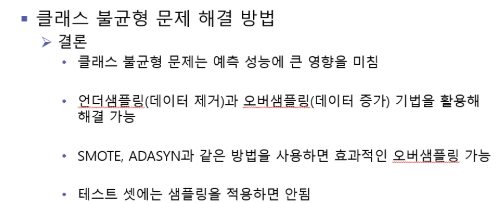

오버샘플링과 언더샘플링은 

> "타겟값(=라벨)의 클래스 분포 불균형을 보정하기 위해 타겟값의 비율을 인위적으로 조정하는 데이터 샘플링 기법"

> "타겟 클래스의 비율"을 조정하여, 학습 데이터의 균형을 맞추고, 모델이 모든 클래스를 학습할 수 있게 하는 기법

In [2]:
# 필요한 패키지 설치
# !pip install imbalanced-learn==0.7.0
# imbalanced-learn 패키지는 클래스 불균형 문제를 해결하기 위한 오버샘플링 및 언더샘플링 도구를 제공함
# 주석 처리된 pip 명령어는 해당 패키지가 설치되지 않은 환경에서만 실행 필요함
# 버전을 명시함으로써 코드 실행의 일관성과 호환성을 확보함

from sklearn.model_selection import train_test_split
# 데이터를 학습용과 테스트용으로 나누기 위한 함수 임포트
# 모델 평가를 위해 훈련 데이터와 검증 데이터를 분리하는 데 사용됨

from imblearn.under_sampling import *
# 모든 언더샘플링 기법 클래스를 imbalanced-learn에서 임포트함
# 대표적으로 RandomUnderSampler, TomekLinks, ClusterCentroids 등 클래스 불균형 문제 완화를 위해 활용됨

from imblearn.over_sampling import SMOTE
# SMOTE(Synthetic Minority Over-sampling Technique) 클래스를 임포트함
# 소수 클래스의 데이터를 선형 보간 방식으로 생성하여 데이터셋을 증강하고 균형을 맞춤

import seaborn as sns
# 통계 시각화 라이브러리 seaborn을 임포트함
# 데이터 분포, 관계 등을 시각적으로 표현하기 위해 사용됨

import matplotlib.pyplot as plt
# matplotlib의 시각화 서브모듈 pyplot을 plt라는 이름으로 임포트함
# 세부 시각화 커스터마이징 및 레이아웃 조정에 활용됨

import pandas as pd
# 데이터 조작 및 분석을 위한 pandas 라이브러리를 임포트함

plt.rcParams['figure.dpi'] = 300
# 출력되는 그래프의 해상도를 300 DPI로 설정하여 시각 품질을 향상함
# 고화질 이미지를 저장하거나 리포트, 논문 제출 시 유용함


In [3]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/dragonheir/logistic-regression
df = pd.read_csv("../../main/datasets/Social_Network_Ads.csv")

# 데이터 샘플 확인
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
# 각 컬럼의 속성 및 결측치 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


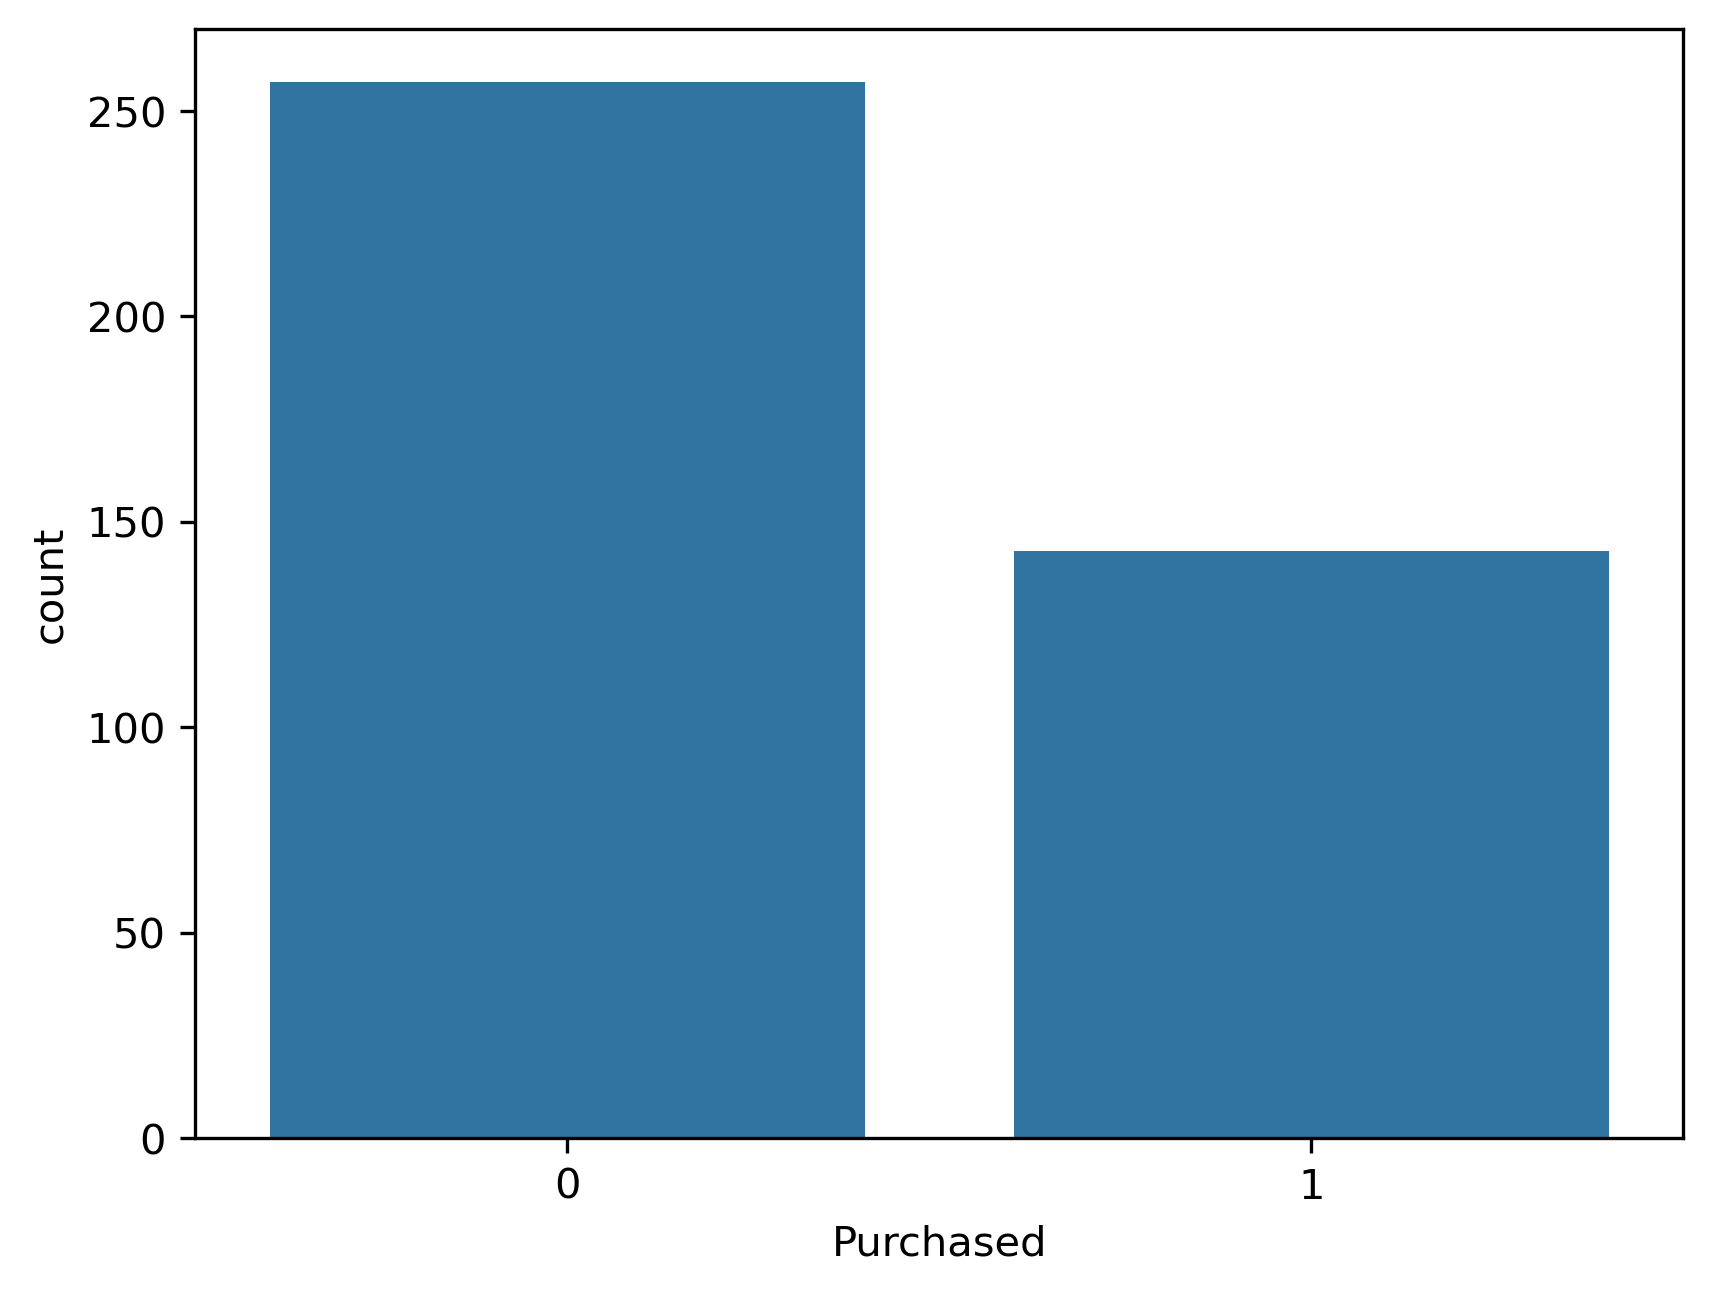

In [5]:
# Purchased 컬럼 클래스 분포 시각화
sns.countplot(x="Purchased", data=df)

plt.show()

In [6]:
# Gender 컬럼 가변수 처리

df_d = pd.get_dummies(df['Gender'])
# 'Gender' 컬럼에 대해 one-hot encoding(가변수 처리)을 수행함
# 결과적으로 'Female'과 'Male' 두 개의 이진 컬럼이 생성됨
# 성별을 수치형 변수로 변환하여 머신러닝 모델 학습에 활용 가능하게 함

df2 = pd.merge(df.drop(['Gender'], axis=1), 
               df_d['Male'], left_index=True, right_index=True, how='inner')
# 원본 데이터프레임(df)에서 'Gender' 컬럼을 제거하고, 'Male' 가변수 컬럼만 병합하여 새로운 데이터프레임(df2)을 생성함
# 병합 기준은 인덱스를 기준으로 하고, how='inner'를 통해 동일한 인덱스에 대해 일치하는 행만 결합함
# 결과적으로 성별 정보는 'Male'이라는 하나의 이진 컬럼으로만 표현됨 (1: 남성, 0: 여성)

df2.head()
# df2 데이터프레임의 상위 5개 행을 출력함
# 가변수 변환 및 병합 결과가 의도대로 잘 수행되었는지 확인하는 단계임


,User ID,Age,EstimatedSalary,Purchased,Male
0,15624510,19,19000,0,1
1,15810944,35,20000,0,1
2,15668575,26,43000,0,0
3,15603246,27,57000,0,0
4,15804002,19,76000,0,1


In [7]:
# 데이터셋 학습셋, 테스트셋 분리

X = df2.drop(['Purchased'], axis=1)
# 목표 변수(Purchased)를 제외한 나머지 컬럼들을 특징 행렬(feature matrix) X로 설정함
# 모델이 학습에 사용할 입력 데이터임

y = df2[['Purchased']]
# 목표 변수인 'Purchased' 컬럼을 레이블 벡터 y로 설정함
# 사용자의 구매 여부(0 또는 1)를 예측하는 이진 분류 문제의 타깃 값임

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=10)
# 전체 데이터셋을 학습용(75%)과 테스트용(25%)으로 분리함
# test_size=0.25는 전체의 25%를 테스트 데이터로 지정함
# random_state=10은 랜덤 분할을 고정시켜 재현성을 확보함
# 결과적으로 총 4개의 데이터셋이 생성됨: 입력(X_train, X_test), 출력(y_train, y_test)

X_train.head()
# 학습용 입력 데이터(X_train)의 상위 5개 행을 출력함
# 분할된 데이터가 의도대로 구성되었는지, 피처 구성이 제대로 유지되었는지 확인하는 단계임


,User ID,Age,EstimatedSalary,Male
57,15807481,28,79000,1
87,15631912,28,85000,0
357,15671387,41,72000,0
355,15606472,60,34000,1
238,15617877,46,82000,0


In [8]:
# 언더샘플링 적용

X_train_under, y_train_under = RandomUnderSampler(random_state=0).fit_resample(X_train, y_train)
# RandomUnderSampler 객체를 생성하고, fit_resample()을 통해 언더샘플링을 적용함
# 언더샘플링은 다수 클래스(예: 구매 안함)가 너무 많아 학습이 치우치는 문제를 방지하기 위한 방법임
# 소수 클래스(예: 구매함)의 샘플 수에 맞춰 다수 클래스 데이터를 무작위로 삭제하여 클래스 균형을 맞춤
# random_state=0은 난수 생성 초기값 고정을 통해 결과 재현성을 확보함
# 반환된 X_train_under, y_train_under은 클래스 비율이 균형을 이룬 학습용 데이터셋임

# # 예: 다수 클래스를 소수 클래스의 1.5배 수준으로 줄임
# undersample = RandomUnderSampler(sampling_strategy=0.6, random_state=0)
# X_under, y_under = undersample.fit_resample(X, y)

print('RandomUnderSampler 적용 전 학습셋 변수/레이블 데이터 세트: ', X_train.shape, y_train.shape)
# 언더샘플링 이전의 입력(X_train)과 출력(y_train) 데이터셋의 크기를 출력함
# 샘플 수가 클래스별로 불균형한 상태의 원본 학습 데이터셋임

print('RandomUnderSampler 적용 후 학습셋 변수/레이블 데이터 세트: ', X_train_under.shape, y_train_under.shape)
# 언더샘플링 적용 후의 입력(X_train_under)과 출력(y_train_under) 데이터셋의 크기를 출력함
# 다수 클래스의 샘플 수가 소수 클래스에 맞춰 줄어든 상태로, 전체 샘플 수가 감소한 것을 확인할 수 있음

print('RandomUnderSampler 적용 전 레이블 값 분포: \n', pd.Series(y_train['Purchased']).value_counts())
# 언더샘플링 전 원본 학습 데이터에서 레이블 'Purchased'의 클래스별 개수를 출력함
# 예: 0 (구매 안함) 이 많고, 1 (구매함) 이 적은 상태 → 불균형 문제를 직관적으로 확인할 수 있음

print('RandomUnderSampler 적용 후 레이블 값 분포: \n', pd.Series(y_train_under['Purchased']).value_counts())
# 언더샘플링 후 학습 데이터에서 레이블 'Purchased'의 클래스별 개수를 출력함
# 두 클래스의 샘플 수가 동일하게 맞춰졌는지 확인함 → 모델 학습 시 클래스 간 균형된 학습 가능


RandomUnderSampler 적용 전 학습셋 변수/레이블 데이터 세트:  (300, 4) (300, 1)
RandomUnderSampler 적용 후 학습셋 변수/레이블 데이터 세트:  (224, 4) (224, 1)
RandomUnderSampler 적용 전 레이블 값 분포: 
 0    188
1    112
Name: Purchased, dtype: int64
RandomUnderSampler 적용 후 레이블 값 분포: 
 0    112
1    112
Name: Purchased, dtype: int64


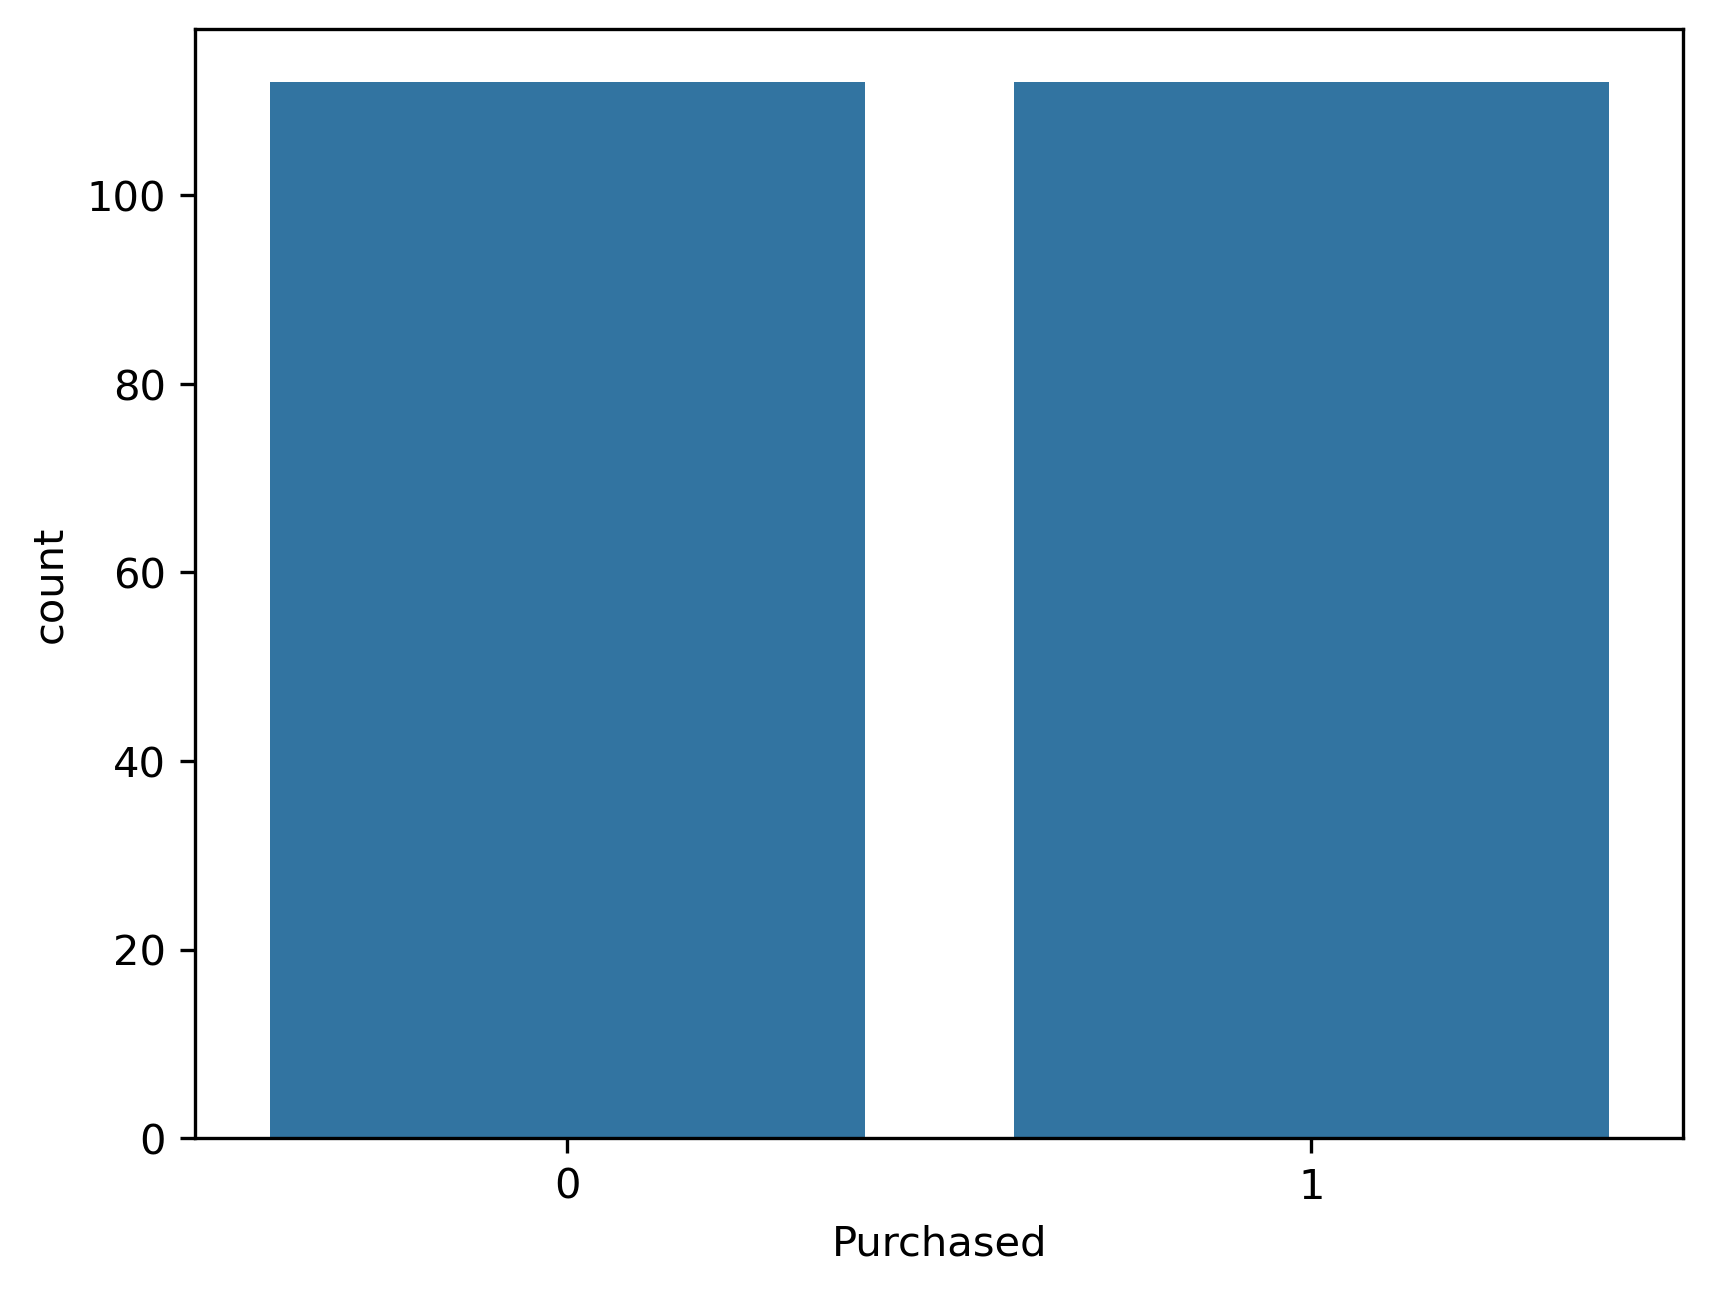

In [9]:
# 언더샘플링 적용 후 Purchased 컬럼 클래스 분포 시각화
sns.countplot(x="Purchased", data=y_train_under)

plt.show()

In [10]:
# 오버샘플링 적용

smote = SMOTE(k_neighbors=2, random_state=0)
# SMOTE(Synthetic Minority Over-sampling Technique) 객체를 생성함
# 소수 클래스 샘플 주변의 k=2개의 최근접 이웃을 기반으로, 새로운 소수 클래스 데이터를 생성함
# random_state=0은 결과의 재현성을 확보하기 위한 설정임

# # 예: 소수 클래스의 샘플 수를 다수 클래스의 70%까지 증가시키고 싶을 경우
# smote = SMOTE(sampling_strategy=0.7, random_state=0)
# X_over, y_over = smote.fit_resample(X, y)

X_train_over, y_train_over = smote.fit_resample(X_train, y_train)
# 학습 데이터(X_train, y_train)에 대해 SMOTE 오버샘플링을 적용함
# 소수 클래스의 데이터가 인위적으로 생성되어, 다수 클래스와의 수가 균형을 이루게 됨
# 반환된 X_train_over, y_train_over는 클래스 비율이 균형을 이룬 학습용 데이터셋임

print('SMOTE 적용 전 학습용 변수/레이블 데이터 세트: ', X_train.shape, y_train.shape)
# 원본 학습 데이터셋의 크기를 출력함 → 샘플 수가 불균형 상태인지 확인하는 지표임

print('SMOTE 적용 후 학습용 변수/레이블 데이터 세트: ', X_train_over.shape, y_train_over.shape)
# 오버샘플링 후의 학습 데이터셋 크기를 출력함
# 소수 클래스 데이터가 인위적으로 생성되었기 때문에 샘플 수가 증가함

print('SMOTE 적용 전 레이블 값 분포: \n', pd.Series(y_train['Purchased']).value_counts())
# 오버샘플링 전의 클래스별 개수(불균형 상태)를 출력함
# 예: 0이 200개, 1이 70개 등 → 클래스 불균형 존재 확인

print('SMOTE 적용 후 레이블 값 분포: \n', pd.Series(y_train_over['Purchased']).value_counts())
# 오버샘플링 적용 후의 클래스별 개수를 출력함
# 소수 클래스가 다수 클래스와 같은 수로 늘어나 균형이 맞춰졌는지 확인하는 단계임


SMOTE 적용 전 학습용 변수/레이블 데이터 세트:  (300, 4) (300, 1)
SMOTE 적용 후 학습용 변수/레이블 데이터 세트:  (376, 4) (376, 1)
SMOTE 적용 전 레이블 값 분포: 
 0    188
1    112
Name: Purchased, dtype: int64
SMOTE 적용 후 레이블 값 분포: 
 0    188
1    188
Name: Purchased, dtype: int64


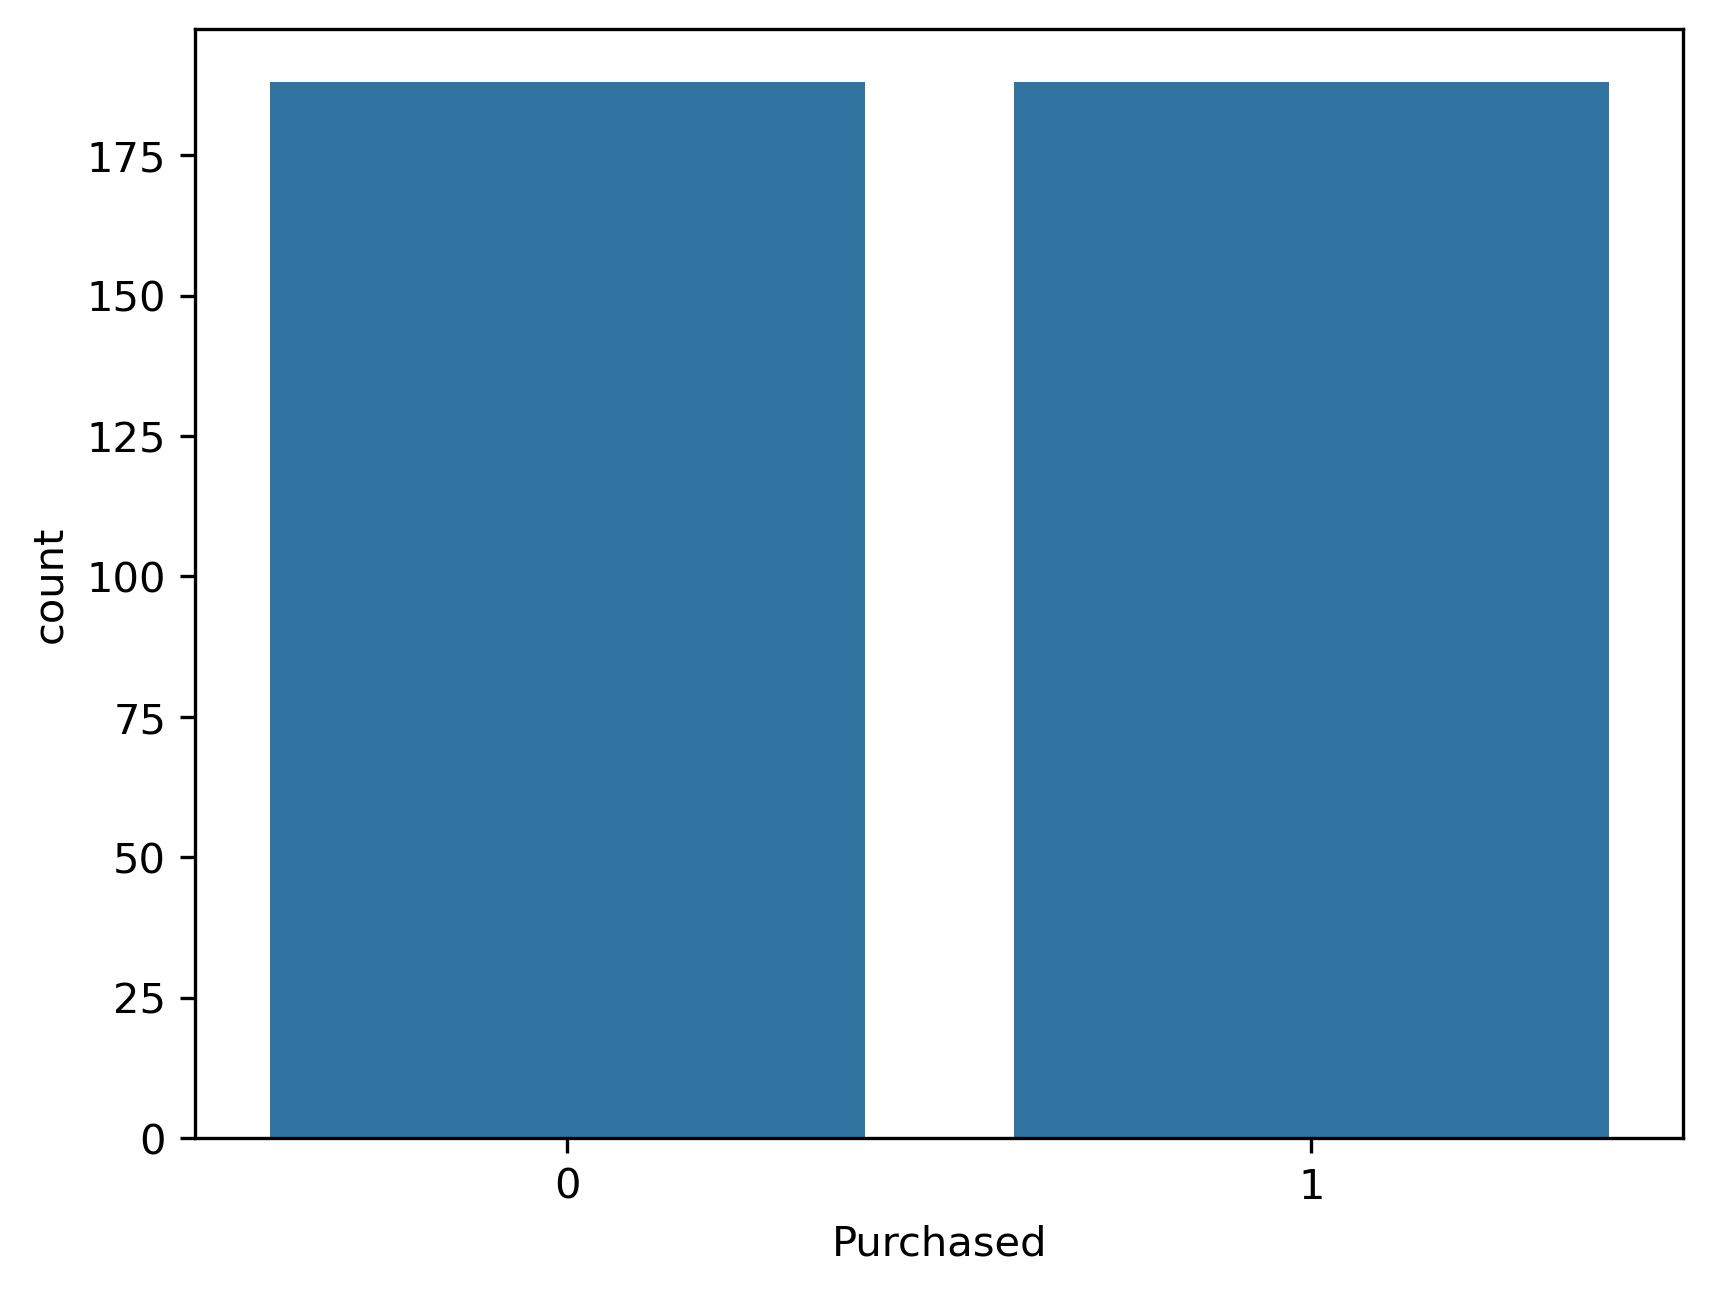

In [11]:
# 오버샘플링 적용 후 Purchased 컬럼 클래스 분포 시각화
sns.countplot(x="Purchased", data=y_train_over)

plt.show()

In [12]:
y_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 300 entries, 57 to 265
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Purchased  300 non-null    int64
dtypes: int64(1)
memory usage: 4.7 KB


In [13]:
X_train_under.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 224 entries, 327 to 265
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          224 non-null    int64
 1   Age              224 non-null    int64
 2   EstimatedSalary  224 non-null    int64
 3   Male             224 non-null    uint8
dtypes: int64(3), uint8(1)
memory usage: 7.2 KB
